<a href="https://colab.research.google.com/github/Rakshitanaik-27/EliteTech-DataScience/blob/main/Task1_Data_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- STEP 1: INGESTING DATASET ---
Dataset Loaded Successfully! Shape: (891, 12)

--- STEP 2: GENERATING MISSING VALUES HEATMAP ---


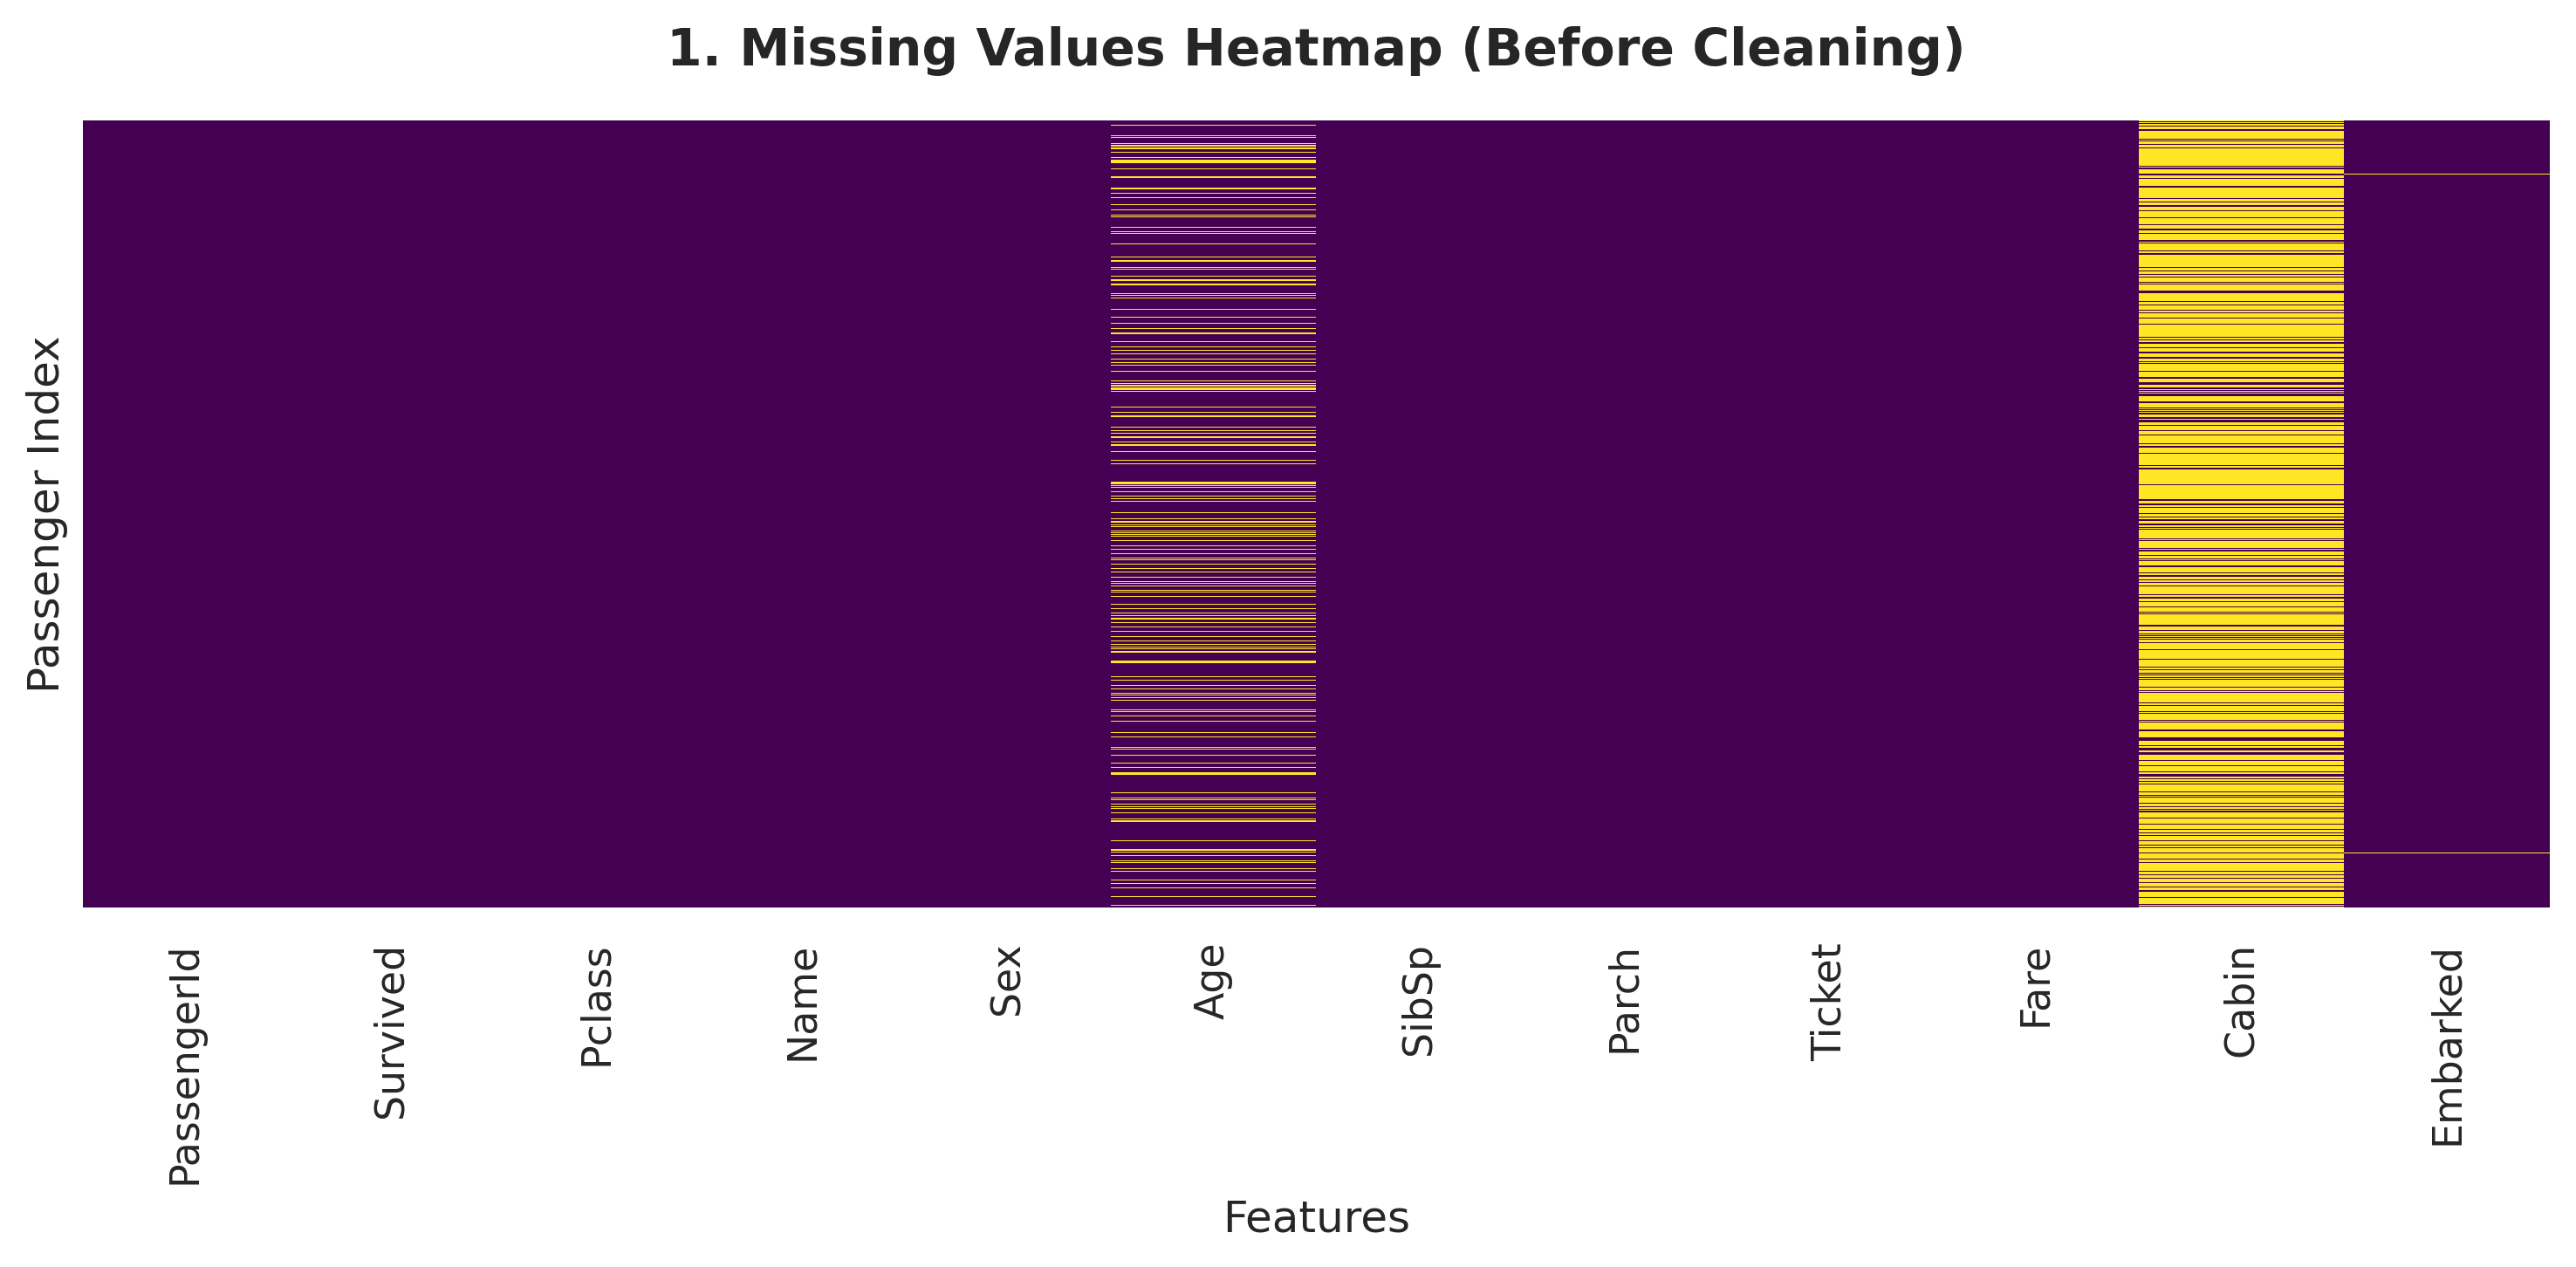


--- STEP 3: TRANSFORMING & CLEANING DATA ---
Data Cleaning Complete. Missing values remaining:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

--- STEP 4: GENERATING VISUAL EDA PLOTS ---


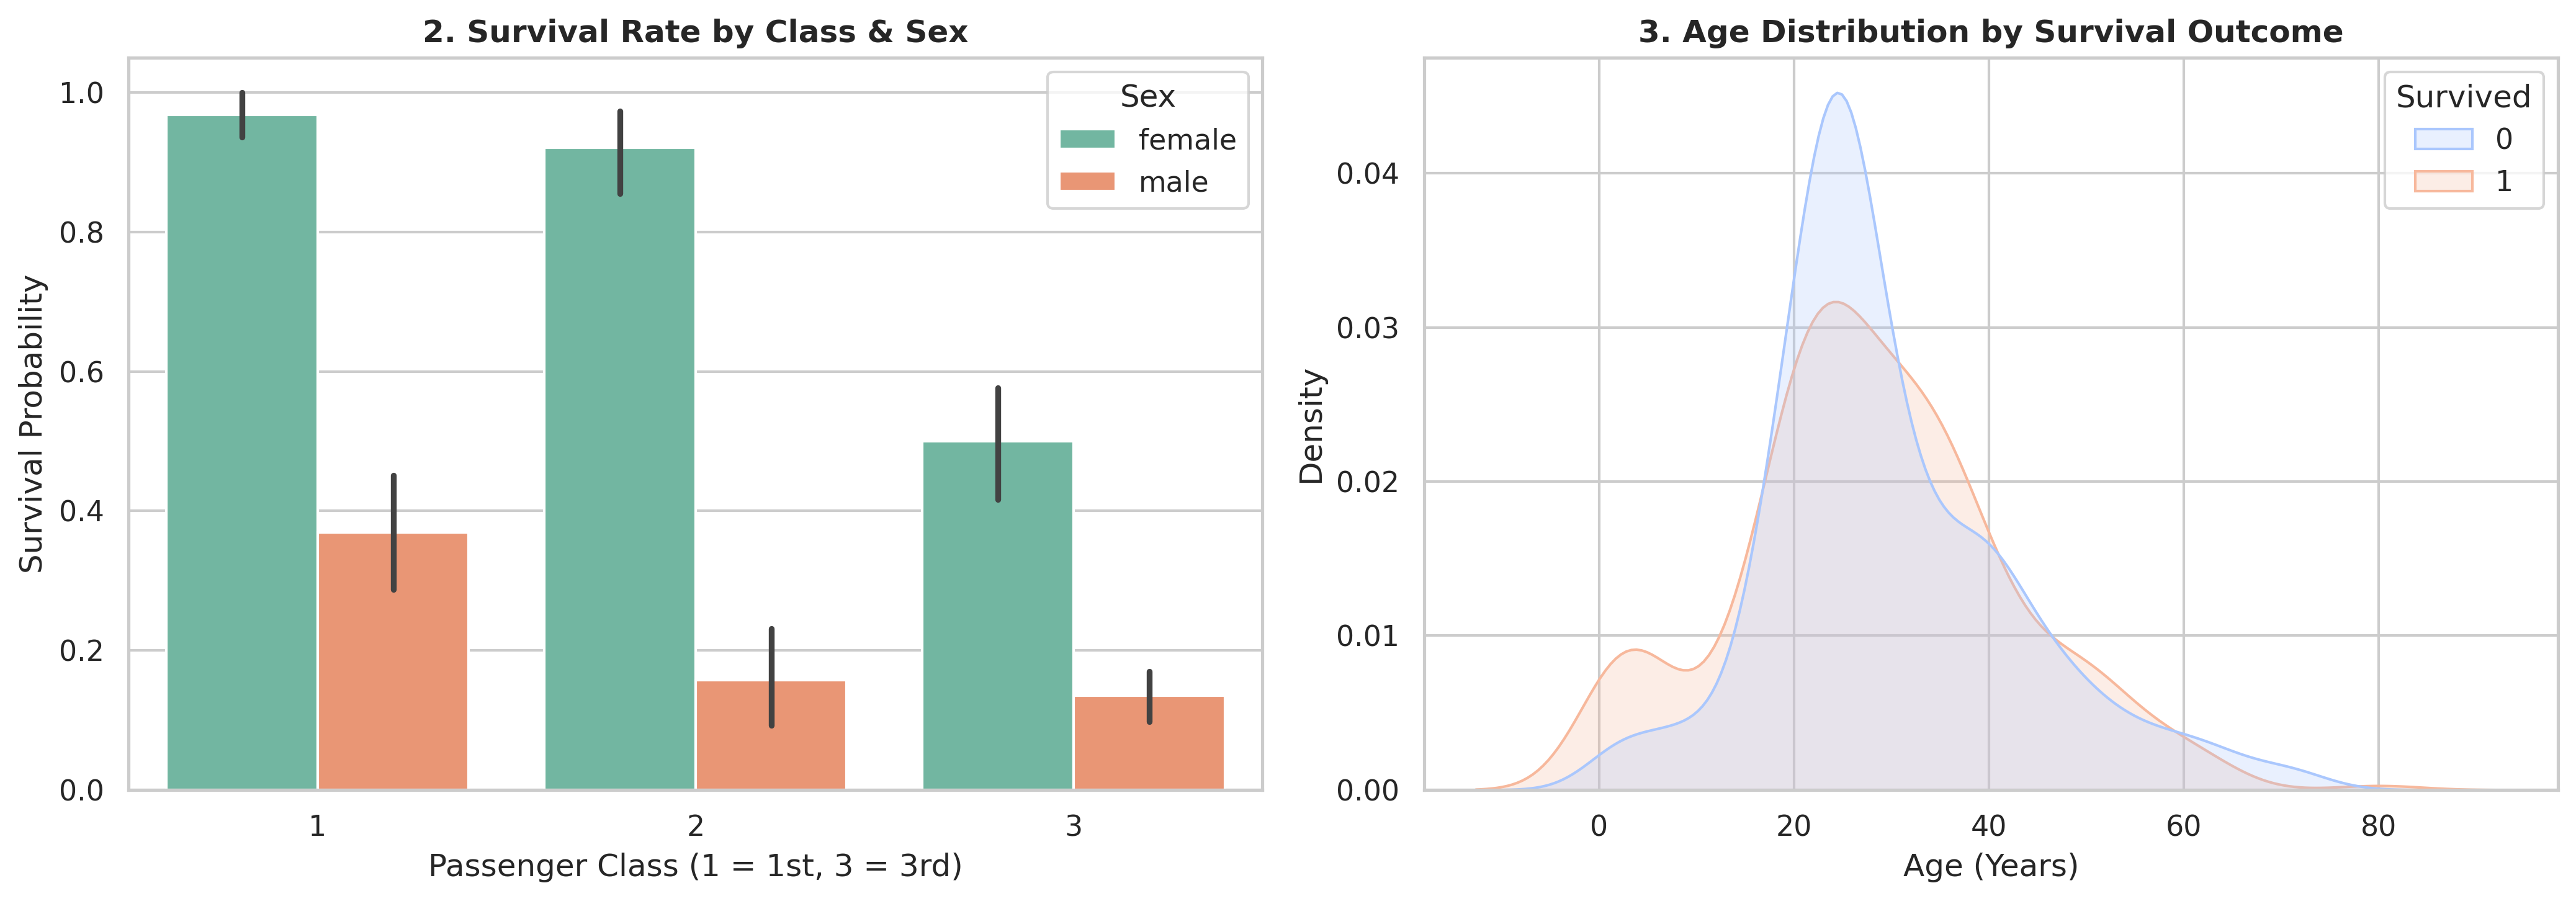

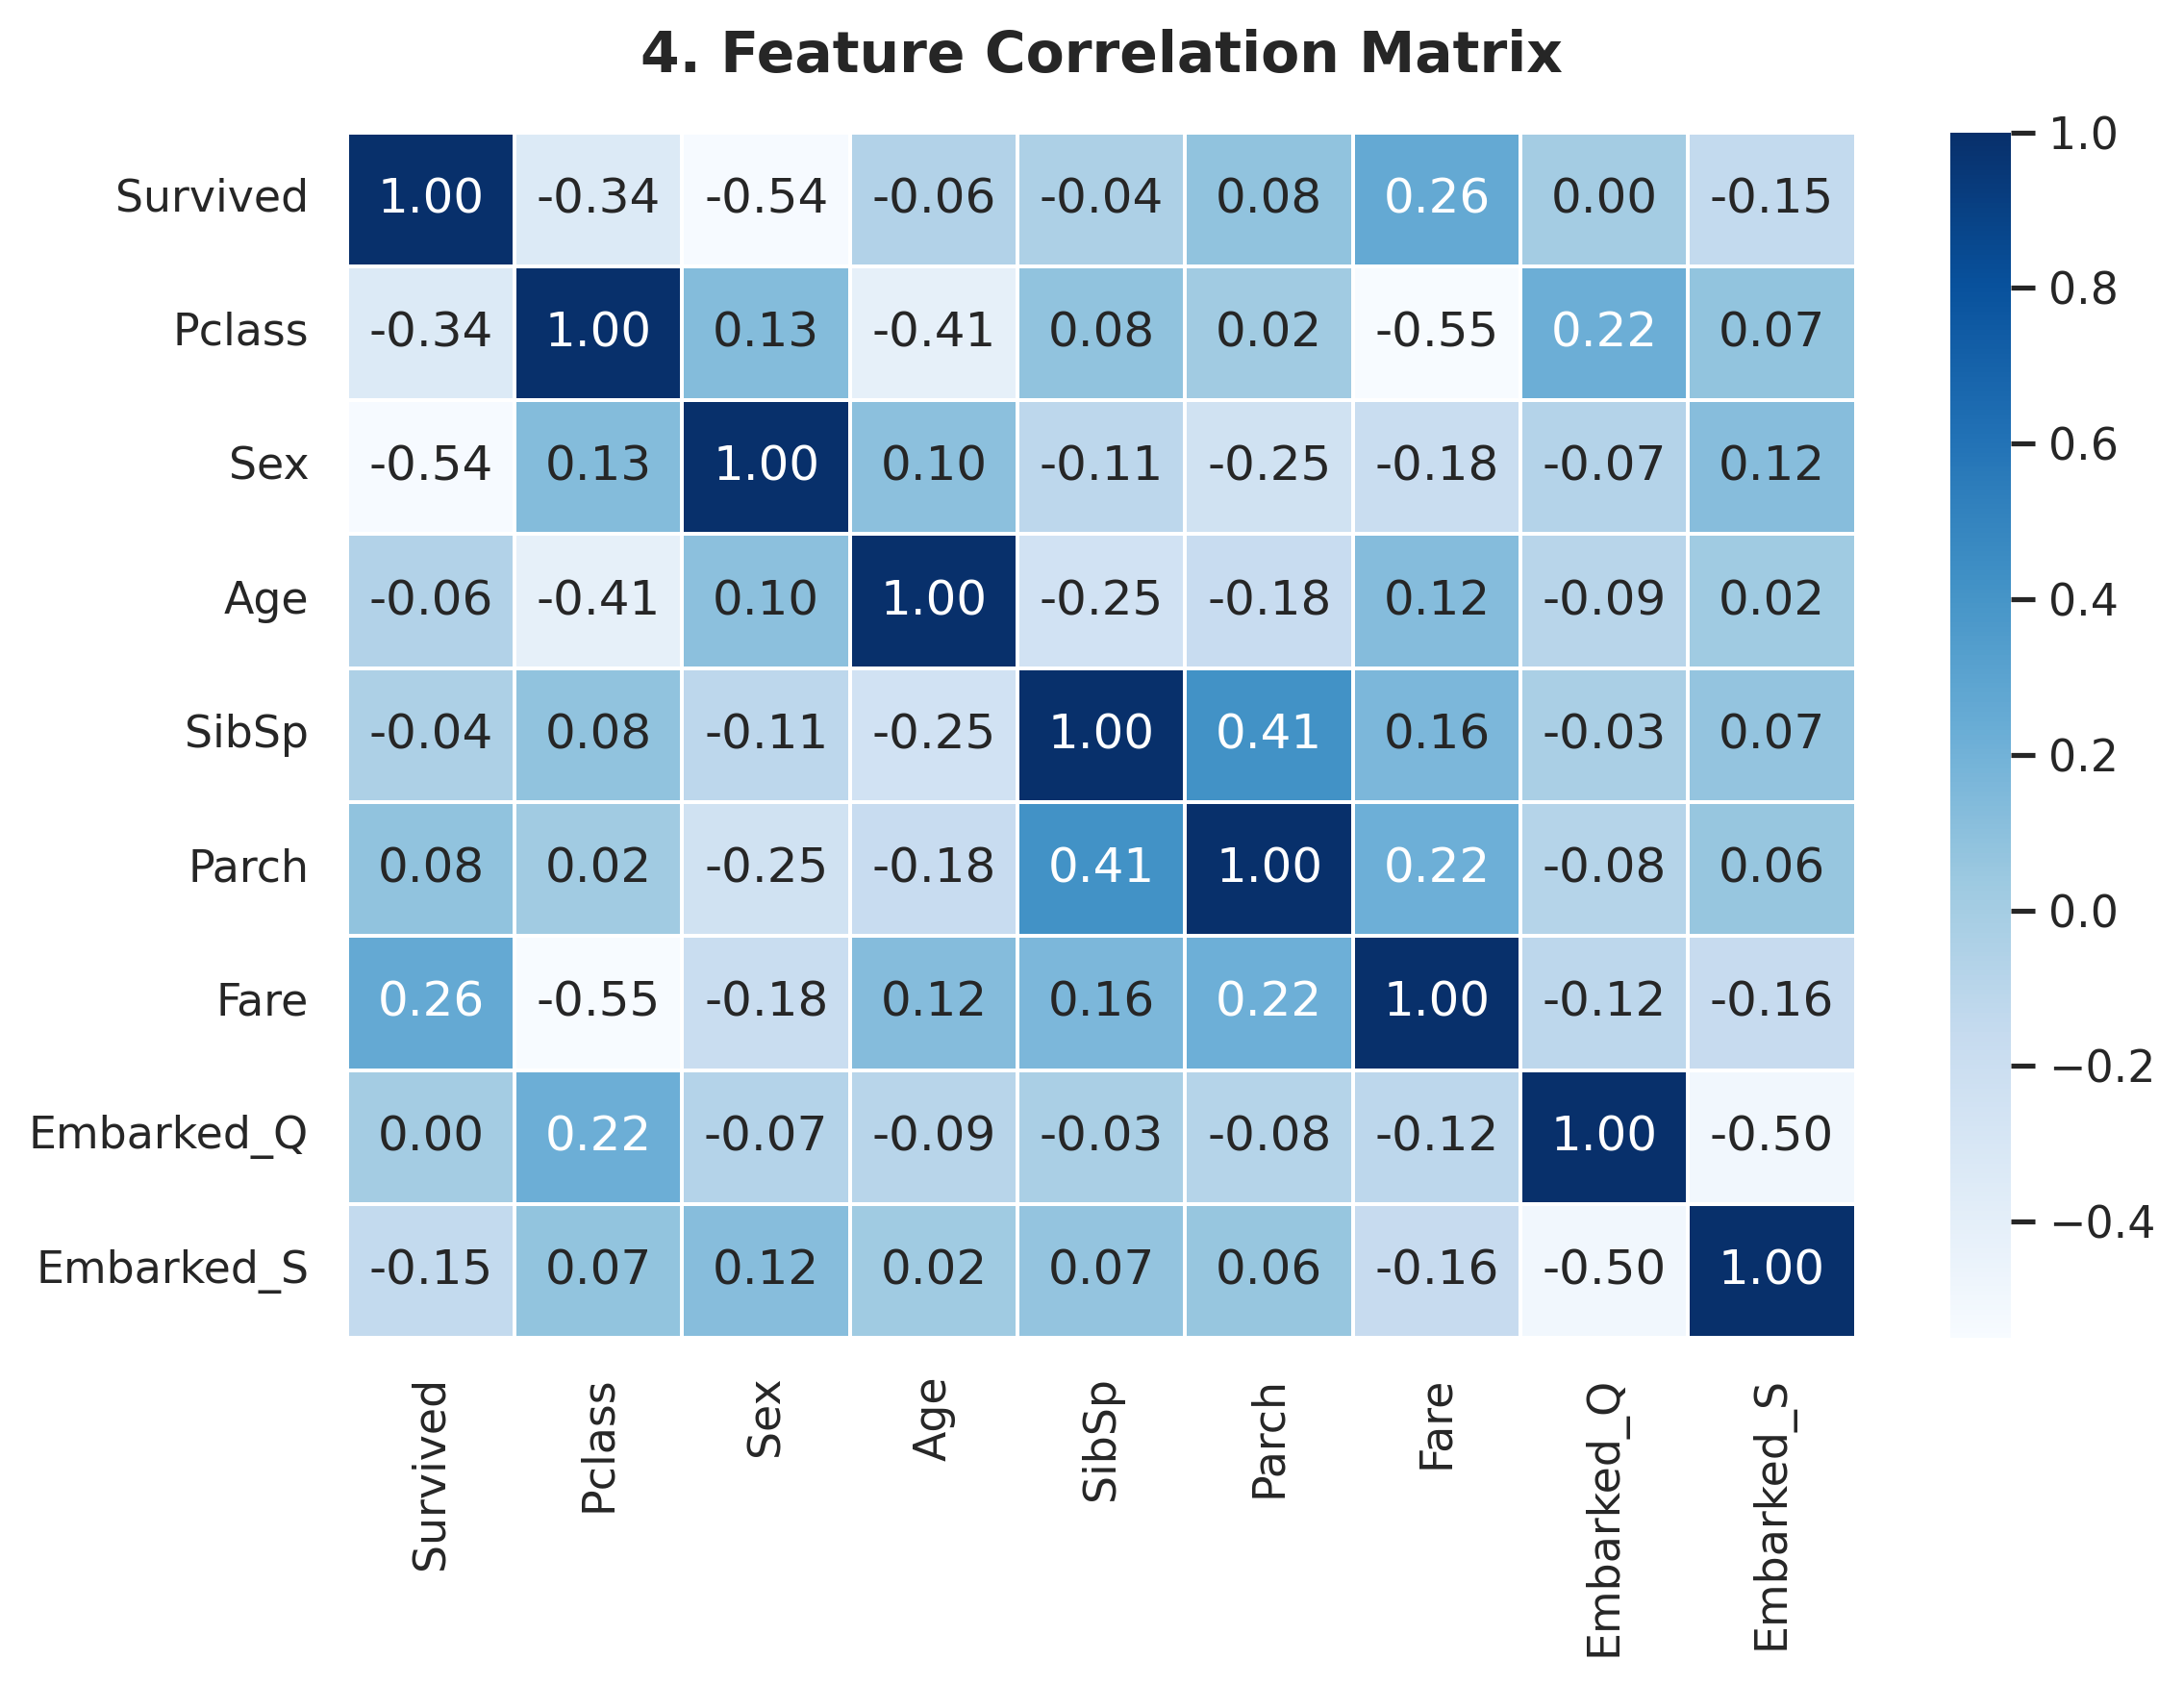


✅ Cleaned dataset successfully exported to 'titanic_cleaned_pipeline.csv'!


In [2]:
# ==============================================================================
# EliteTech Intern - Task 1: Data Pipeline & Processing (ETL & EDA)
# Dataset: Titanic Dataset
# Output: Cleaned DataFrame + Visual EDA Plots for LinkedIn Screenshots
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for clean, high-quality figures
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300  # High resolution for post screenshots

# ------------------------------------------------------------------------------
# STEP 1: DATA INGESTION (EXTRACT)
# ------------------------------------------------------------------------------
print("--- STEP 1: INGESTING DATASET ---")
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Dataset Loaded Successfully! Shape: {df.shape}\n")

# ------------------------------------------------------------------------------
# STEP 2: VISUALIZE MISSING VALUES (HEATMAP)
# ------------------------------------------------------------------------------
print("--- STEP 2: GENERATING MISSING VALUES HEATMAP ---")

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('1. Missing Values Heatmap (Before Cleaning)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Features')
plt.ylabel('Passenger Index')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# STEP 3: DATA CLEANING & TRANSFORMATION (TRANSFORM)
# ------------------------------------------------------------------------------
print("\n--- STEP 3: TRANSFORMING & CLEANING DATA ---")

# 1. Fill missing 'Age' values with median age based on Sex and Pclass
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# 2. Fill missing 'Embarked' with the most frequent value (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Drop 'Cabin' column (too many missing values) and unnecessary identifiers
df_cleaned = df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket']).copy()

# 4. Feature Encoding
df_cleaned['Sex'] = df_cleaned['Sex'].map({'female': 0, 'male': 1})
df_cleaned = pd.get_dummies(df_cleaned, columns=['Embarked'], drop_first=True)

print("Data Cleaning Complete. Missing values remaining:")
print(df_cleaned.isnull().sum())

# ------------------------------------------------------------------------------
# STEP 4: VISUAL EXPLORATORY DATA ANALYSIS (EDA PLOTS)
# ------------------------------------------------------------------------------
print("\n--- STEP 4: GENERATING VISUAL EDA PLOTS ---")

# Figure 1: Survival Rate by Passenger Class and Sex
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', palette='Set2', ax=axes[0])
axes[0].set_title('2. Survival Rate by Class & Sex', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Survival Probability')
axes[0].set_xlabel('Passenger Class (1 = 1st, 3 = 3rd)')

# Figure 2: Age Distribution by Survival Outcome
sns.kdeplot(data=df, x='Age', hue='Survived', common_norm=False, palette='coolwarm', fill=True, ax=axes[1])
axes[1].set_title('3. Age Distribution by Survival Outcome', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age (Years)')

plt.tight_layout()
plt.show()

# Figure 3: Correlation Heatmap of Transformed Features
plt.figure(figsize=(8, 6))
sns.heatmap(df_cleaned.corr(), annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('4. Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# STEP 5: SAVE CLEANED PIPELINE OUTPUT (LOAD)
# ------------------------------------------------------------------------------
df_cleaned.to_csv("titanic_cleaned_pipeline.csv", index=False)
print("\n✅ Cleaned dataset successfully exported to 'titanic_cleaned_pipeline.csv'!")